## Imports e setup

In [4]:
import os
import random
from pathlib import Path
from collections import Counter
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from sklearn.metrics.pairwise import rbf_kernel
from scipy.spatial.distance import pdist

from utils.drift_detection import plot_image_property_drift, extract_properties, save_props

In [5]:
ORIGINAL_DIR = Path("../original_datasets")
PREPROC_DIR = Path("../preprocessed_datasets")
OUT_DIR = Path("../eda_outputs")
OUT_DIR.mkdir(exist_ok=True)
NUM_PROC = max(1, (os.cpu_count() or 1) - 1)
BATCH_SIZE = 128

In [6]:
imagenet_r_raw = load_from_disk(ORIGINAL_DIR / "imagenet_r")
imagenet_1k_raw = load_from_disk(ORIGINAL_DIR / "imagenet-1k")
imagenet_r_pre = load_from_disk(PREPROC_DIR / "imagenet_r_preprocessed")
imagenet_1k_pre = load_from_disk(PREPROC_DIR / "imagenet_1k_preprocessed")

imagenet_c_brightness_sev_1 = load_from_disk(ORIGINAL_DIR / "imagenet_c_datasets" / "brightness_sev_1")
imagenet_c_brightness_sev_2 = load_from_disk(ORIGINAL_DIR / "imagenet_c_datasets" / "brightness_sev_2")
imagenet_c_brightness_sev_3 = load_from_disk(ORIGINAL_DIR / "imagenet_c_datasets" / "brightness_sev_3")
# other..

imagenet_c = {
    "ImageNet-C (brightness, sev 1)": imagenet_c_brightness_sev_1,
    "ImageNet-C (brightness, sev 2)": imagenet_c_brightness_sev_2,
    "ImageNet-C (brightness, sev 3)": imagenet_c_brightness_sev_3,
    # other..
}

datasets_dict = {
    "ImageNet-R (raw)": imagenet_r_raw,
    "ImageNet-1k val (raw)": imagenet_1k_raw,
    "ImageNet-R (preprocessed)": imagenet_r_pre,
    "ImageNet-1k val (preprocessed, 200 classi)": imagenet_1k_pre,

    "ImageNet-C": imagenet_c
}

## Analisi esplorativa

### Struttura dei dataset

In [5]:
for name, ds in datasets_dict.items():
    print(f"\n{name}")
    print(ds)


ImageNet-R (raw)
Dataset({
    features: ['image', 'wnid', 'class_name'],
    num_rows: 30000
})

ImageNet-1k val (raw)
Dataset({
    features: ['image', 'label'],
    num_rows: 50000
})

ImageNet-R (preprocessed)
Dataset({
    features: ['image', 'wnid', 'class_name', 'ik_label'],
    num_rows: 30000
})

ImageNet-1k val (preprocessed, 200 classi)
Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})

ImageNet-C
{'ImageNet-C (brightness, sev 1)': Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
}), 'ImageNet-C (brightness, sev 2)': Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
}), 'ImageNet-C (brightness, sev 3)': Dataset({
    features: ['image', 'wnid', 'label'],
    num_rows: 50000
})}


### Distribuzioni di classe

In [6]:
def class_distribution(dataset, label_col, name):
    """Ritorna una Series con il conteggio di esempi per classe."""
    counts = Counter(dataset[label_col])
    s = pd.Series(counts).sort_index()
    print(f"\n{name}: {len(s)} classi distinte, "
          f"min={s.min()}, max={s.max()}, media={s.mean():.1f}, std={s.std():.1f}")
    return s


ImageNet-R (raw): 200 classi distinte, min=51, max=430, media=150.0, std=72.5

ImageNet-1k preprocessed: 200 classi distinte, min=50, max=50, media=50.0, std=0.0


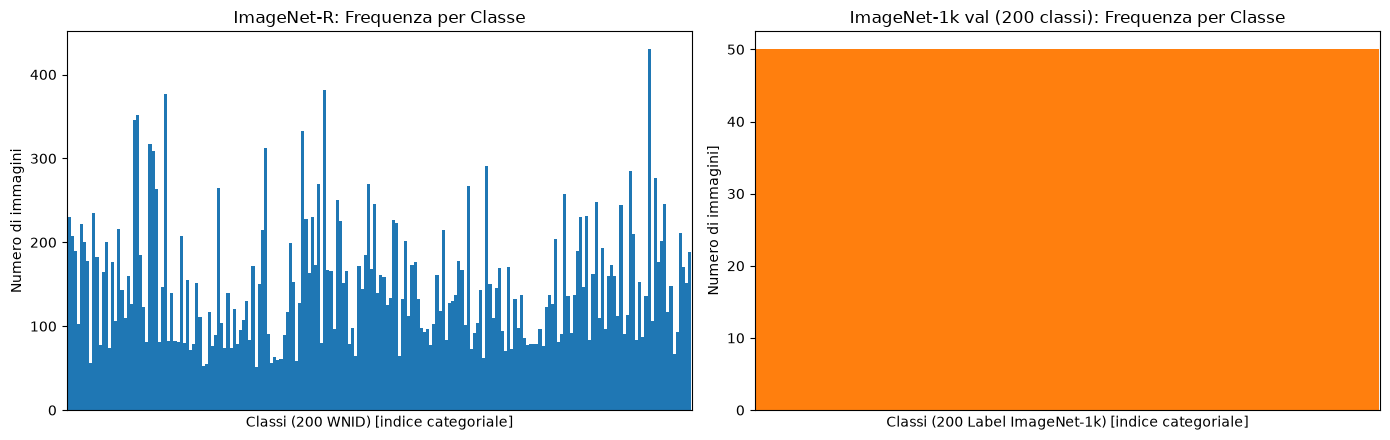

In [7]:
# TODO: Capire come comportarsi, il dataset imagenet_r è molto sbilanciato
r_dist = class_distribution(imagenet_r_raw, "wnid", "ImageNet-R (raw)")
ik_pre_dist = class_distribution(imagenet_1k_pre, "label", "ImageNet-1k preprocessed")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

r_dist.plot(kind="bar", ax=axes[0], width=1.0, color="#1f77b4")
axes[0].set_title("ImageNet-R: Frequenza per Classe")
axes[0].set_xticks([])
axes[0].set_xlabel("Classi (200 WNID) [indice categoriale]")
axes[0].set_ylabel("Numero di immagini")

ik_pre_dist.plot(kind="bar", ax=axes[1], width=1.0, color="#ff7f0e")
axes[1].set_title("ImageNet-1k val (200 classi): Frequenza per Classe")
axes[1].set_xticks([])
axes[1].set_xlabel("Classi (200 Label ImageNet-1k) [indice categoriale]")
axes[1].set_ylabel("Numero di immagini]")

plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=150)
plt.show()

#### Overlap delle classi

In [8]:
r_wnids = set(imagenet_r_raw["wnid"])
r_ik_labels = set(imagenet_r_pre["label"])
ik_pre_labels = set(imagenet_1k_pre["label"])
 
print(f"\nWNID distinti in ImageNet-R: {len(r_wnids)}")
print(f"Indici ImageNet-1k coperti da ImageNet-R (via mapping): {len(r_ik_labels)}")
print(f"Indici presenti in ImageNet-1k preprocessato: {len(ik_pre_labels)}")
print(f"Le due liste di indici coincidono esattamente: {r_ik_labels == ik_pre_labels}")

if r_ik_labels != ik_pre_labels:
    print("Differenza:", r_ik_labels.symmetric_difference(ik_pre_labels))



WNID distinti in ImageNet-R: 200
Indici ImageNet-1k coperti da ImageNet-R (via mapping): 200
Indici presenti in ImageNet-1k preprocessato: 200
Le due liste di indici coincidono esattamente: True


#### Proprietà delle immagini

In [9]:
def _image_props_batch(batch, image_col):
    widths, heights, modes = [], [], []
    for img in batch[image_col]:
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)
    return {"width": widths, "height": heights, "mode": modes}

In [10]:
def full_image_stats(dataset, image_col="image", name=""):
    """Calcola width/height/mode per OGNI immagine del dataset."""
    ds_props = dataset.map(
        _image_props_batch,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROC,
        fn_kwargs={"image_col": image_col},
        desc=f"Proprietà immagini - {name}",
    )
    df = ds_props.select_columns(["width", "height", "mode"]).to_pandas()
    print(f"\n{name}: analizzate tutte le {len(df)} immagini")
    print(df[["width", "height"]].describe())
    print("Modalità colore:", dict(Counter(df["mode"])))
    return df

In [11]:
r_img_stats = full_image_stats(imagenet_r_raw, name="ImageNet-R")
ik_img_stats = full_image_stats(imagenet_1k_pre, name="ImageNet-1k val")


ImageNet-R: analizzate tutte le 30000 immagini
              width        height
count  30000.000000  30000.000000
mean     480.303767    459.184600
std      258.020546    246.666393
min       19.000000     30.000000
25%      374.000000    350.000000
50%      499.000000    441.000000
75%      500.000000    500.000000
max     7016.000000   5833.000000
Modalità colore: {'RGB': 28752, 'L': 1164, 'CMYK': 84}

ImageNet-1k val: analizzate tutte le 10000 immagini
              width        height
count  10000.000000  10000.000000
mean     487.810000    424.156700
std      173.387566    148.992971
min       67.000000     83.000000
25%      450.000000    375.000000
50%      500.000000    375.000000
75%      500.000000    500.000000
max     4048.000000   3072.000000
Modalità colore: {'RGB': 9820, 'L': 180}


#### Statistiche sui pixel

In [ ]:
def _pixel_stats_batch(batch, image_col):
    import numpy as np
    means, stds = [], []
    for img in batch[image_col]:
        arr = np.asarray(img.convert("RGB"), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))   # media per canale R,G,B
        stds.append(arr.std(axis=(0, 1)))
    means = np.array(means)
    stds = np.array(stds)
    return {
        "mean_r": means[:, 0], "mean_g": means[:, 1], "mean_b": means[:, 2],
        "std_r": stds[:, 0], "std_g": stds[:, 1], "std_b": stds[:, 2],
    }

In [ ]:
def full_pixel_stats(dataset, image_col="image", name=""):
    """Calcola media e deviazione standard RGB per OGNI immagine.
    Nota: più lento della versione campionata, perché decodifica ogni
    immagine del dataset — con dataset grandi può richiedere diversi minuti."""
    ds_pix = dataset.map(
        _pixel_stats_batch,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROC,
        fn_kwargs={"image_col": image_col},
        desc=f"Statistiche pixel - {name}",
    )
    cols = ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b"]
    df = ds_pix.select_columns(cols).to_pandas()
    means = df[["mean_r", "mean_g", "mean_b"]].to_numpy()
    stds = df[["std_r", "std_g", "std_b"]].to_numpy()
    print(f"\n{name} - immagini analizzate: {len(df)}")
    print(f"{name} - media canali RGB: {means.mean(axis=0).round(3)}")
    print(f"{name} - std canali RGB:   {stds.mean(axis=0).round(3)}")
    return means, stds

In [ ]:
r_means, r_stds = full_pixel_stats(imagenet_r_raw, name="ImageNet-R")
ik_means, ik_stds = full_pixel_stats(imagenet_1k_pre, name="ImageNet-1k val")


ImageNet-R - immagini analizzate: 30000
ImageNet-R - media canali RGB: [0.62  0.594 0.557]
ImageNet-R - std canali RGB:   [0.231 0.227 0.23 ]

ImageNet-1k val - immagini analizzate: 10000
ImageNet-1k val - media canali RGB: [0.463 0.444 0.391]
ImageNet-1k val - std canali RGB:   [0.232 0.227 0.228]


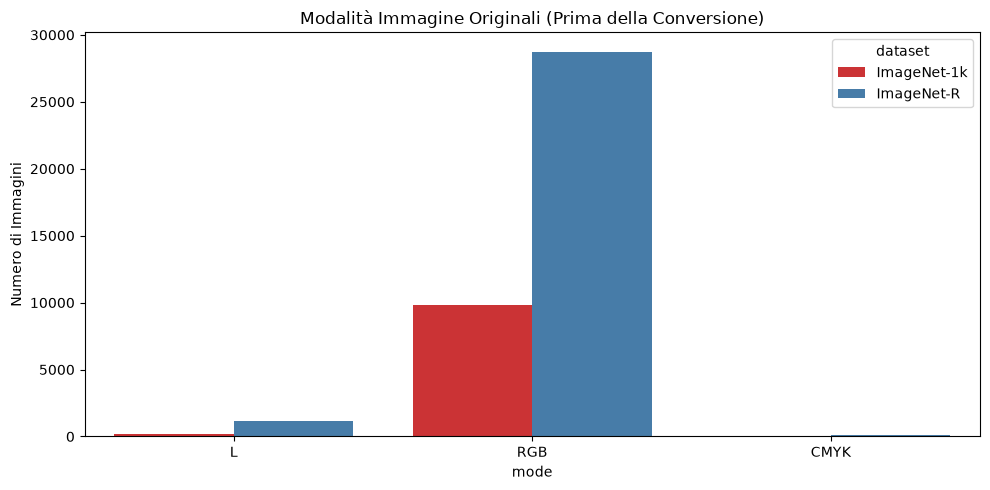

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ik_img_stats["dataset"] = "ImageNet-1k"
r_img_stats["dataset"] = "ImageNet-R"
df_all = pd.concat([ik_img_stats, r_img_stats], ignore_index=True)

mode_df = df_all.groupby(['dataset', 'mode']).size().reset_index(name='count')
sns.barplot(data=mode_df, x='mode', y='count', hue='dataset', ax=ax, palette="Set1")

ax.set_title("Modalità Immagine Originali (Prima della Conversione)")
ax.set_ylabel("Numero di Immagini")

plt.tight_layout()
plt.show()

## Analisi del drift

### Drift Detection sulle feature delle immagini

In [12]:
props = extract_properties(imagenet_1k_pre)
save_props(props, "cache/imagenet1k_props.pkl")

Extracting:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved → cache/imagenet1k_props.pkl


ImageNet-R (pre):   0%|          | 0/30000 [00:00<?, ?it/s]

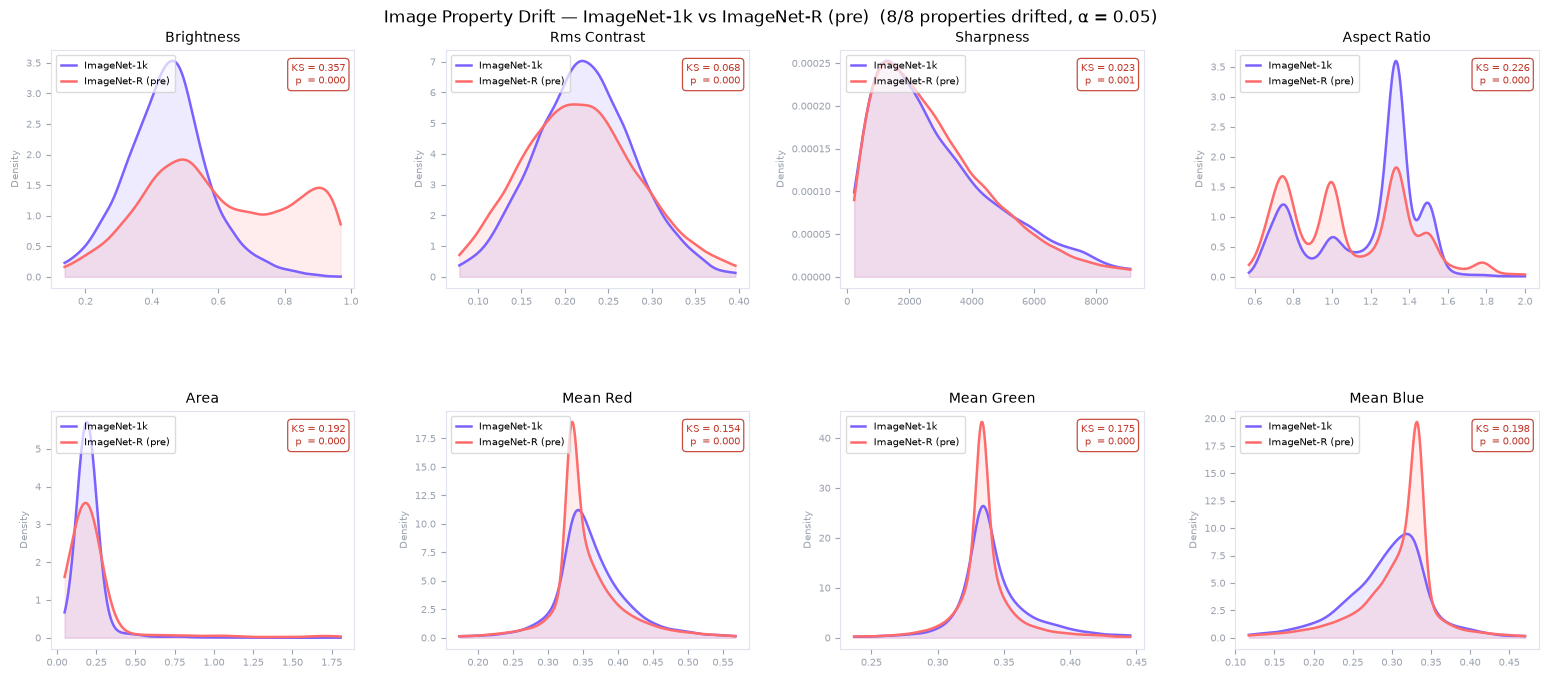

In [13]:
ks_pre = plot_image_property_drift(
        dataset_b=imagenet_r_pre,
        label_a="ImageNet-1k",
        label_b="ImageNet-R (pre)",
        props_a="cache/imagenet1k_props.pkl",
        )

In [14]:
print("\nStatistiche di drift tra ImageNet-1k e ImageNet-R (pre):")
display(ks_pre)


Statistiche di drift tra ImageNet-1k e ImageNet-R (pre):


,KS Statistic,p-value,Drift
Property,,,
Brightness,0.3572,0.0000,yes
Rms Contrast,0.0676,0.0000,yes
Sharpness,0.0229,0.0008,yes
Aspect Ratio,0.2255,0.0000,yes
Area,0.1920,0.0000,yes
Mean Red,0.1540,0.0000,yes
Mean Green,0.1752,0.0000,yes
Mean Blue,0.1983,0.0000,yes


ImageNet-C (brightness, sev 1):   0%|          | 0/50000 [00:00<?, ?it/s]

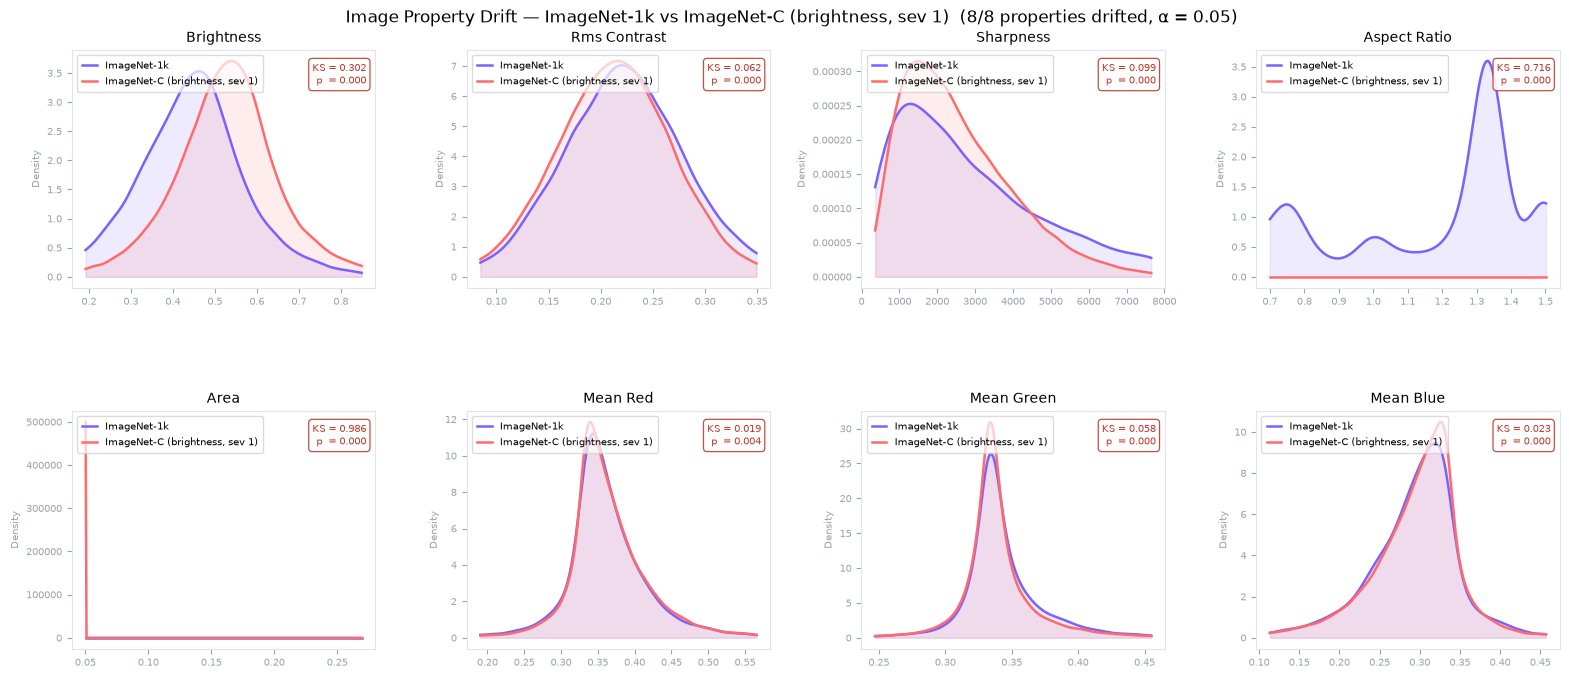


Statistiche di drift tra ImageNet-1k (pre) e ImageNet-C (brightness, sev 1):


,KS Statistic,p-value,Drift
Property,,,
Brightness,0.3017,0.0000,yes
Rms Contrast,0.0617,0.0000,yes
Sharpness,0.0991,0.0000,yes
Aspect Ratio,0.7164,0.0000,yes
Area,0.9860,0.0000,yes
Mean Red,0.0193,0.0039,yes
Mean Green,0.0578,0.0000,yes
Mean Blue,0.0226,0.0004,yes


ImageNet-C (brightness, sev 2):   0%|          | 0/50000 [00:00<?, ?it/s]

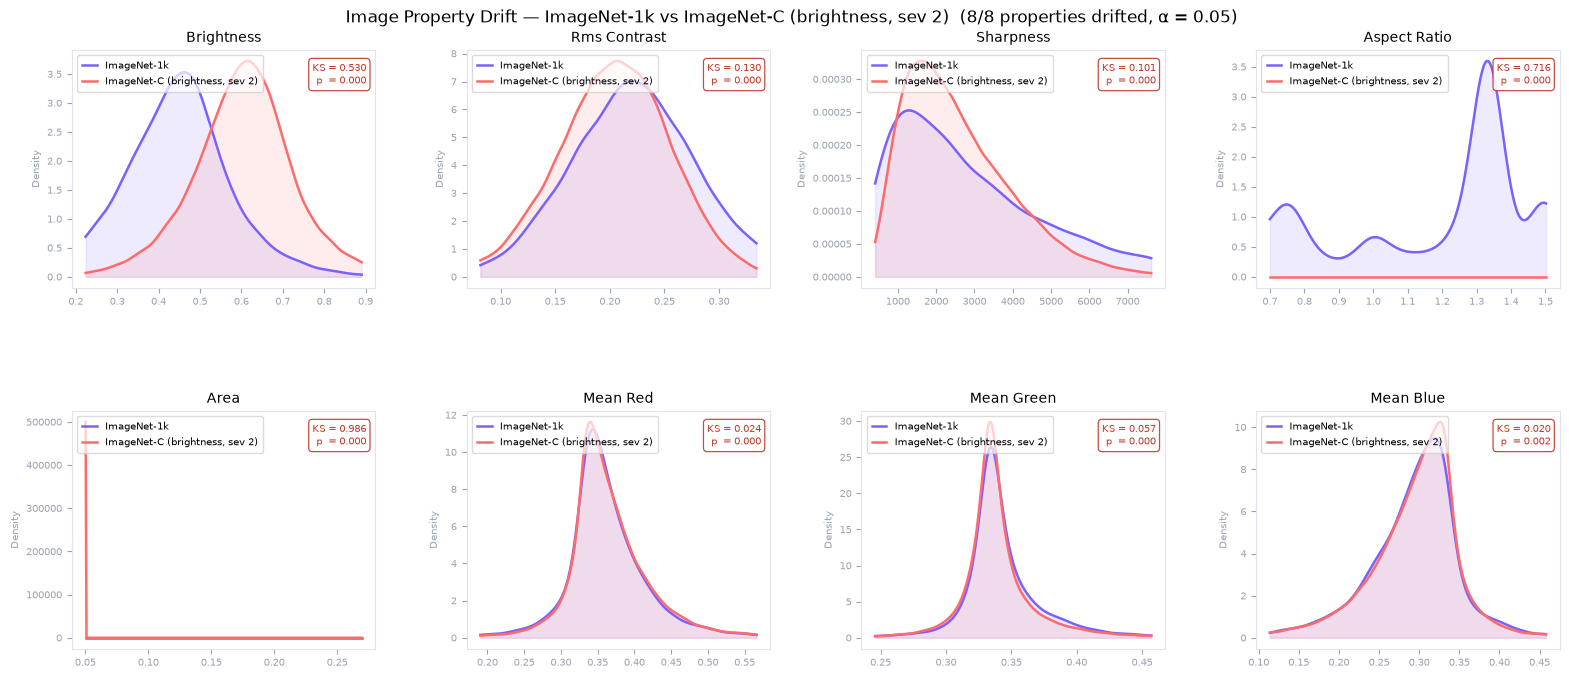


Statistiche di drift tra ImageNet-1k (pre) e ImageNet-C (brightness, sev 2):


,KS Statistic,p-value,Drift
Property,,,
Brightness,0.5299,0.0000,yes
Rms Contrast,0.1295,0.0000,yes
Sharpness,0.1014,0.0000,yes
Aspect Ratio,0.7164,0.0000,yes
Area,0.9860,0.0000,yes
Mean Red,0.0240,0.0001,yes
Mean Green,0.0568,0.0000,yes
Mean Blue,0.0203,0.0020,yes


ImageNet-C (brightness, sev 3):   0%|          | 0/50000 [00:00<?, ?it/s]

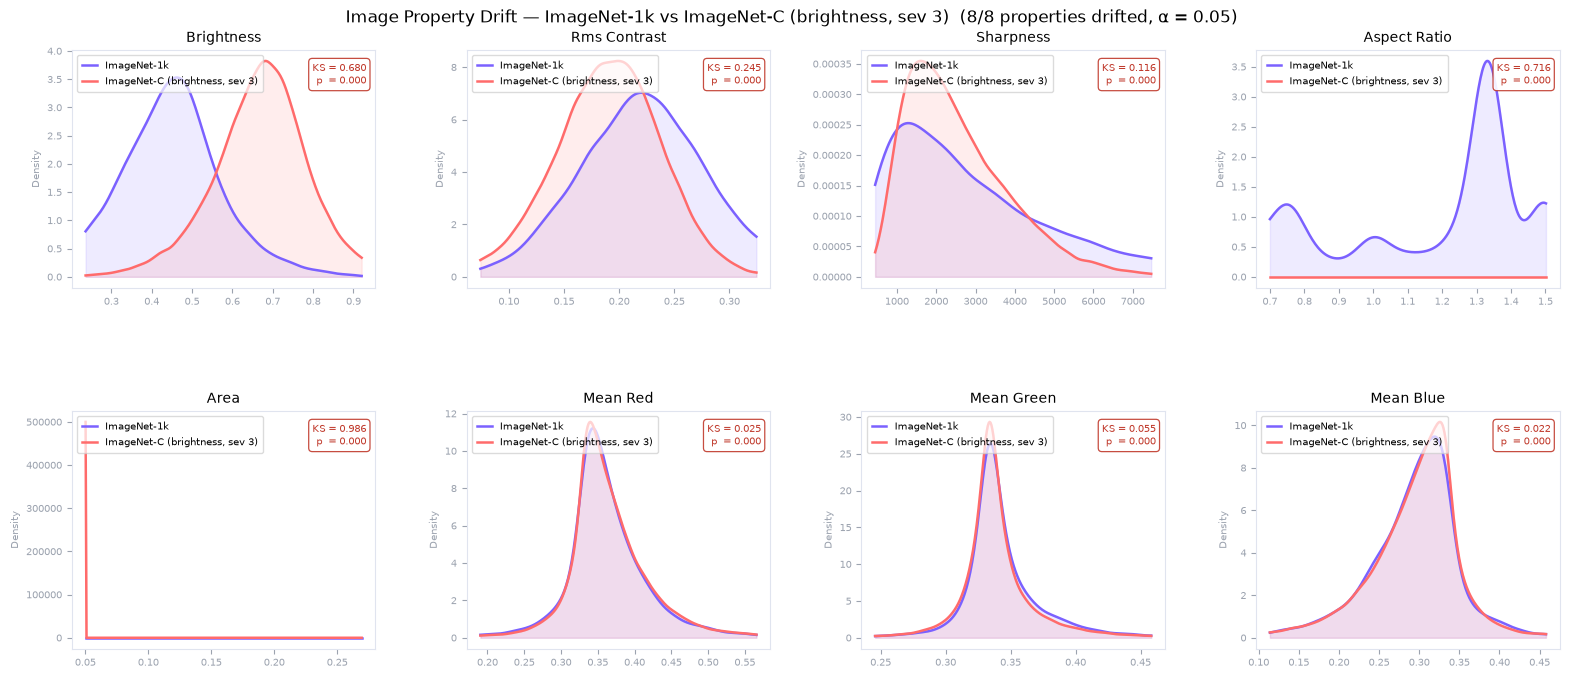


Statistiche di drift tra ImageNet-1k (pre) e ImageNet-C (brightness, sev 3):


,KS Statistic,p-value,Drift
Property,,,
Brightness,0.6798,0.0000,yes
Rms Contrast,0.2454,0.0000,yes
Sharpness,0.1159,0.0000,yes
Aspect Ratio,0.7164,0.0000,yes
Area,0.9860,0.0000,yes
Mean Red,0.0249,0.0001,yes
Mean Green,0.0549,0.0000,yes
Mean Blue,0.0225,0.0004,yes


In [15]:
import importlib, utils.drift_detection as dd
importlib.reload(dd)
from utils.drift_detection import plot_image_property_drift

for name, ds in imagenet_c.items():
    ks_c = plot_image_property_drift(
        dataset_b = ds,
        label_a = "ImageNet-1k",
        label_b = name,
        props_a="cache/imagenet1k_props.pkl",
    )
    print(f"\nStatistiche di drift tra ImageNet-1k (pre) e {name}:")
    display(ks_c)

### Misura del drift con MMD (Maximum Mean Discrepancy)

In [1]:
def rbf_kernel_batch(X, Y, gamma, batch_size=512):
    """Calcola rbf_kernel(X, Y) a blocchi senza materializzare tutto in memoria."""
    n, m = len(X), len(Y)
    result = np.zeros((n, m), dtype=np.float32)
    
    for i in range(0, n, batch_size):
        X_batch = X[i:i+batch_size]
        for j in range(0, m, batch_size):
            Y_batch = Y[j:j+batch_size]
            result[i:i+batch_size, j:j+batch_size] = rbf_kernel(X_batch, Y_batch, gamma)
    
    return result

def mmd_rbf_batched(X, Y, gamma=None, batch_size=512):
    if gamma is None:
        # stima gamma su un subsample per non calcolare pdist su tutto
        sample = np.vstack([X, Y])
        idx = np.random.choice(len(sample), min(2000, len(sample)), replace=False)
        gamma = 1.0 / (2 * np.median(pdist(sample[idx])) ** 2)
    
    XX = rbf_kernel_batch(X, X, gamma, batch_size)
    YY = rbf_kernel_batch(Y, Y, gamma, batch_size)
    XY = rbf_kernel_batch(X, Y, gamma, batch_size)
    
    return XX.mean() + YY.mean() - 2 * XY.mean()

In [17]:
def mmd_permutation_test(X, Y, mmd_stat, n_perm=500, gamma=None):
    combined = np.vstack([X, Y])
    n = len(X)
    
    # calcola le kernel matrix UNA VOLTA SOLA
    K = rbf_kernel_batch(combined, combined, gamma)
    
    null_stats = []
    for _ in range(n_perm):
        idx = np.random.permutation(len(combined))
        # estrai sottoblocchi dalla matrice già calcolata
        K_perm = K[np.ix_(idx, idx)]
        XX = K_perm[:n, :n].mean()
        YY = K_perm[n:, n:].mean()
        XY = K_perm[:n, n:].mean()
        null_stats.append(XX + YY - 2 * XY)
        print(f"Permutazione {_+1}/{n_perm} completata", end="\r")
    
    null_stats = np.array(null_stats)
    p_value = np.mean(null_stats >= mmd_stat)

    plt.figure(figsize=(7, 4))
    plt.hist(null_stats, bins=30, alpha=0.7, label="Distribuzione nulla (permutazioni)")
    plt.axvline(mmd_stat, color="red", linestyle="--", linewidth=2,
                label=f"MMD osservato = {mmd_stat:.4f}")
    plt.xlabel("MMD")
    plt.ylabel("Frequenza")
    plt.title(f"Permutation test MMD (p-value = {p_value:.4f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mmd_stat, p_value, null_stats

In [7]:
feat_1k = pd.read_csv("../images_features/baseline_features.csv")
feat_r = pd.read_csv("../images_features/drift_features.csv")

In [8]:
mmd_stat = mmd_rbf_batched(feat_1k.values, feat_r.values)

In [11]:
mmd_stat

np.float32(0.05360067)

In [ ]:
mmd_stat, p_value = mmd_permutation_test(feat_1k.values, feat_r.values, mmd_stat, n_perm=100)